## Section 1: Setup 

In [276]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

#setting the global seed in order to maintain reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Environment ready.")

Environment ready.


In [277]:

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 110,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

COLORS = {
    'Hinge': '#e63946',
    'Logistic':    '#457b9d',
    'Squared':     '#2a9d8f',
}
print("Setup complete.")

Setup complete.


## Section 2: Functions to Load/Generate Data

In [203]:
# generate dataset using a gaussian
def generate_data_gaussian(n_samples = 200, separable = True):
    n_class_samples = n_samples // 2    # integer division in order to have a balanced dataset
    if separable:
        pos_mean = [4.0, 4.0] #center the gaussian in 2,2
        neg_mean = [-4.0,-4.0] #center the gaussian in -2,-2
    else:
        pos_mean = [0.8,0.8] #center the gaussian in 0.8,0.8 (less distance from the separation = more noise)
        neg_mean = [-0.8,-0.8] #center the gaussian in -0.8,-0.8 (less distance from the separation = more noise)
    
    #covariance in order to have a symmetric oval shape
    cov = [[1.0, 0.3],[0.3, 1.0]]

    #generate the points
    X_pos = np.random.multivariate_normal(pos_mean, cov, n_class_samples)
    X_neg = np.random.multivariate_normal(neg_mean, cov, n_class_samples)

    #vertical stacking of the matrix
    X = np.vstack((X_pos, X_neg))

    #generate the y classification as +1 and -1
    y = np.ones(n_samples) #generate a vector of 1s
    y[n_class_samples:] = -1 #set the last half samples as -1s

    #shuffle the set in order to not have 100 +1 followed by 100 -1s 
    indices = np.arange(n_samples) #generate numbers from 0 to n_samples
    np.random.shuffle(indices) #shuffle the numbers

    #idx = np.random.permutation(n_samples)

    return X[indices], y[indices]

In [204]:
def generate_data_basic(n_samples=200, separable=True, noise_level=0.10):

    #generate uniformally data between -3 and 3
    X = np.random.uniform(-3,3, (n_samples,2))

    #apply classes based on the straight line x1 - x2 = 0 : if x1 - x2 >= 0 -> +1, otherwise -> -1
    y = np.where(X[:,0] - X[:,1] >= 0, 1.0, -1.0)

    #if not separable add noise
    if not separable:
        n_noise = int(n_samples*noise_level)    #calculate how many point to change
        noise_indexes = np.random.choice(n_samples, n_noise, replace=False)     #randomly extract the indexes of the points to change
        y[noise_indexes] = -y[noise_indexes]     # -1 becomes +1 and +1 becomes -1
    
    return X, y

In [205]:
#Load the Iris Dataset for classification
from sklearn.datasets import load_iris

def load_real_dataset():
    iris = load_iris()
    X = iris.data
    y = iris.target

    binary_mask = y != 2
    X_binary = X[binary_mask]
    y_binary = y[binary_mask]

    X_real = X_binary[:,:2]     #use only Sepal Lenght and Sepal Width
    y_real = np.where(y_binary == 0, 1.0, -1.0)

    indices = np.arange(X_real.shape[0])
    np.random.shuffle(indices)
    
    #idx = np.random.permutation(X_real.shape[0])

    return X_real[indices], y_real[indices]

## Visualize Datasets

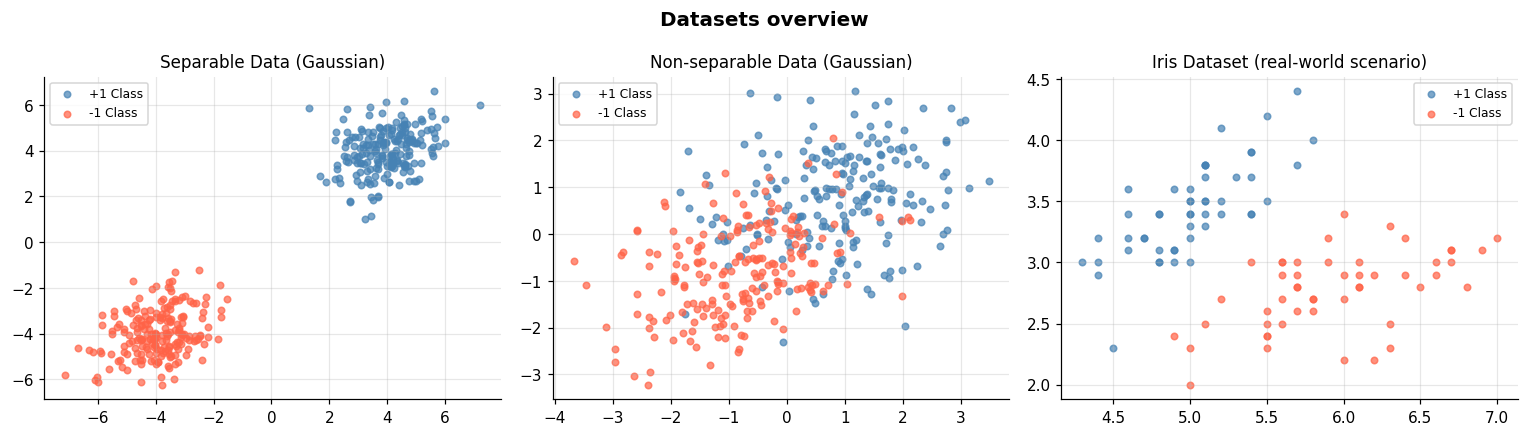

In [206]:
X_sep,  y_sep  = generate_data_gaussian(400, separable=True)
X_ns,   y_ns   = generate_data_gaussian(400, separable=False)
X_real, y_real = load_real_dataset()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (X, y, title) in zip(axes, [
    (X_sep,  y_sep,  'Separable Data (Gaussian)'),
    (X_ns,   y_ns,   'Non-separable Data (Gaussian)'),
    (X_real, y_real, 'Iris Dataset (real-world scenario)'),
]):
    ax.scatter(X[y== 1, 0], X[y== 1, 1], c='steelblue', s=18, alpha=0.7, label='+1 Class')
    ax.scatter(X[y==-1, 0], X[y==-1, 1], c='tomato',    s=18, alpha=0.7, label='-1 Class')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=8)
plt.suptitle('Datasets overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 3: General Functions 

In [207]:
def split_scale_set(X,y, test_size=0.25, scale = False, random_seed=None):
    n_samples = X.shape[0]
    split_index = int(n_samples*test_size)

    rng = np.random.default_rng(random_seed)
    idx = rng.permutation(n_samples)
    X_shuffled, y_shuffled = X[idx], y[idx]

    X_test, X_train = X_shuffled[:split_index], X_shuffled[split_index:]
    y_test, y_train = y_shuffled[:split_index], y_shuffled[split_index:]

    if scale:
        means = np.mean(X_train, axis=0)
        stds = np.std(X_train, axis = 0)

        X_train = (X_train - means) / stds
        X_test = (X_test - means) / stds

    return X_train, X_test, y_train, y_test

In [208]:
def plot_dataset(X, y, title="Dataset Visualization"):
    #single plot figure
    plt.figure(figsize=(8,6))

    #mask positive and negative points
    X_pos = X[y==1]
    X_neg = X[y==-1]

    plt.scatter(X_pos[:,0],X_pos[:,1], color='blue', label= '+1 Class', alpha=0.7, edgecolors='k',s = 40)
    plt.scatter(X_neg[:,0],X_neg[:,1], color='red', label= '-1 Class', alpha=0.7, edgecolors='k',s = 40)

    plt.title(title,fontsize=14,fontweight='bold')
    plt.xlabel('Feature 1', fontsize=12)
    plt.ylabel('Feature 2', fontsize=12)

    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='best',fontsize=11)

    plt.show()

## Section 3: Loss and Gradients Definition

In [209]:
#Zero-one error used for evaluation
#Input: w = weight vector with bias as first element, X = array of data, y = array of labels
#Output: mean 
#
def zero_one_error(w, X, y):
    preds = np.sign(X @ w)
    preds[preds == 0] = -1      #as convention, if the point lands on hyperplane
    return np.mean(preds !=y)

### Hinge Loss

In [210]:
#
#Regularized hinge loss over the full dataset
#Input: w = weight vector with bias as first element, X = array of data, y = array of labels, lam = regularization parameter
#Output: mean hinge loss + regularizer (bias excluded)
#
def hinge_loss(w, X, y, lam):
    #mean over all examples
    margins = y * (X @ w)
    hinge = np.mean(np.maximum(0,1-margins))
    reg = (lam/2) * np.sum(w[1:]**2)
    return hinge+reg


#Hinge gradient per sample
#Input: w = weight vector with bias as first element, x_t = sample from data, y_t = sample from labels, lam = regularization parameter
#Output: gradient step 
def hinge_grad(w, x_t, y_t, lam):
    margin = y_t * np.dot(w, x_t)
    if margin < 1:
        grad = (-y_t * x_t).copy() #gradient
    else:
        grad = np.zeros_like(w)
    
    grad[1:] += lam * w[1:]
    return grad

### Logistic Loss

In [211]:
#
#Regularized logistic loss over the full dataset
#Input: w = weight vector with bias as first element, X = array of data, y = array of labels, lam = regularization parameter
#Output: mean logistic loss + regularizer (bias excluded)
#
def logistic_loss(w, X, y , lam):
    margins = y * (X @ w)
    logistic = np.mean(np.log(1 + np.exp(-margins)))
    reg = (lam / 2) * np.sum(w[1:] ** 2)
    return logistic + reg

#Logistic gradient per sample
#Input: w = weight vector with bias as first element, x_t = sample from data, y_t = sample from labels, lam = regularization parameter
#Output: gradient step 
def logistic_grad(w, x_t, y_t, lam):
    margin = y_t * np.dot(w,x_t)
    sigma = 1.0 / (1.0 + np.exp(margin))

    grad = (-sigma * y_t * x_t).copy()
    grad[1:] += lam * w[1:]

    return grad

### Squared Loss

In [212]:
#
#Regularized squared loss over the full dataset
#Input: w = weight vector with bias as first element, X = array of data, y = array of labels, lam = regularization parameter
#Output: mean squared loss + regularizer (bias excluded)
#
def squared_loss(w, X, y, lam):
    margins = y * (X @ w)
    squared = np.mean((1 - margins)**2)
    reg = (lam / 2) * np.sum(w[1:] ** 2)
    return squared + reg

#Squared gradient per sample
#Input: w = weight vector with bias as first element, x_t = sample from data, y_t = sample from labels, lam = regularization parameter
#Output: gradient step 
def squared_grad(w, x_t, y_t, lam):
    margin = y_t * np.dot(w, x_t)
    grad = (-2 * (1 - margin) * y_t * x_t).copy()   # -2 could be absorbed by the derivate
    #grad = (-(1-margin)* y_t * x_t).copy()

    grad[1:] += lam * w[1:]
    
    return grad


In [ ]:
# Sanity check: print loss values at key margin values
print("Loss values at key margins (no regularization):")
print(f"  {'margin':>8} {'hinge':>10} {'logistic':>10} {'squared':>10} {'0-1':>6}")
print("  " + "-" * 48)
for m in [-1.0, 0.0, 0.5, 1.0, 2.0, 3.0]:
    h = max(0.0, 1 - m)
    l = float(np.log(1 + np.exp(-m)))
    s = (1 - m) ** 2
    z = int(m <= 0)
    print(f"  {m:>8.1f} {h:>10.4f} {l:>10.4f} {s:>10.4f} {z:>6}")
print()
print("  Key: at m=2.0 squared=1.0 — same penalty as m=0 (on the boundary)!")
print("       hinge=0.0 and logistic≈0.13 correctly give near-zero for m=2.0.")

print(f"Loss values at key margins using loss functions defined")
print(f"  {'margin':>8} {'hinge':>10} {'logistic':>10} {'squared':>10} {'0-1':>6}")
print("  " + "-" * 48)

lam = 0.0

for m in [-1.0, 0.0, 0.5, 1.0, 2.0, 3.0]:

    X_test = np.array([[1.0]]) #(1,1)
    y_test = np.array([1.0])   #(1,)
    w_test = np.array([m])     #(1,)

    h = hinge_loss(w_test,X_test, y_test, lam)
    l = logistic_loss(w_test,X_test, y_test, lam)
    s = squared_loss(w_test,X_test, y_test, lam)
    z = zero_one_error(w_test, X_test, y_test)
    print(f"  {m:>8.1f} {h:>10.4f} {l:>10.4f} {s:>10.4f} {z:>6}")

LOSSES = {
    'Hinge' : (hinge_loss, hinge_grad),
    'Logistic' : (logistic_loss, logistic_grad),
    'Squared' : (squared_loss, squared_grad),
}



Loss values at key margins (no regularization):
    margin      hinge   logistic    squared    0-1
  ------------------------------------------------
      -1.0     2.0000     1.3133     4.0000      1
       0.0     1.0000     0.6931     1.0000      1
       0.5     0.5000     0.4741     0.2500      0
       1.0     0.0000     0.3133     0.0000      0
       2.0     0.0000     0.1269     1.0000      0
       3.0     0.0000     0.0486     4.0000      0

  Key: at m=2.0 squared=1.0 — same penalty as m=0 (on the boundary)!
       hinge=0.0 and logistic≈0.13 correctly give near-zero for m=2.0.
Loss values at key margins using loss functions defined
    margin      hinge   logistic    squared    0-1
  ------------------------------------------------
      -1.0     2.0000     1.3133     4.0000    1.0
       0.0     1.0000     0.6931     1.0000    1.0
       0.5     0.5000     0.4741     0.2500    0.0
       1.0     0.0000     0.3133     0.0000    0.0
       2.0     0.0000     0.1269     1.00

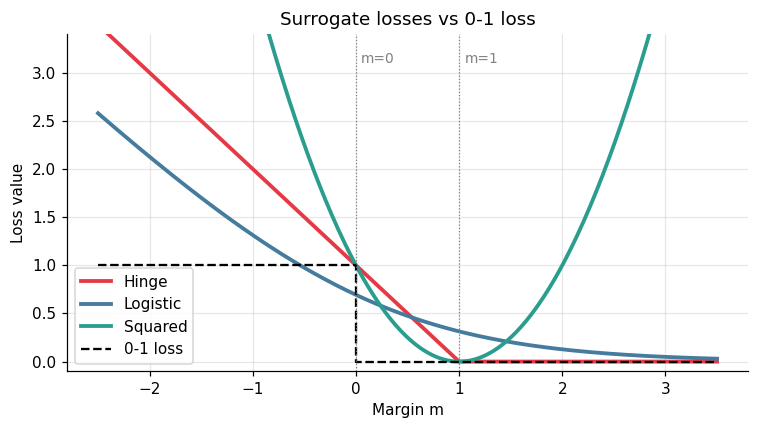

In [ ]:
m_vals = np.linspace(-2.5, 3.5, 400)

plt.figure(figsize=(7, 4))
plt.plot(m_vals, np.maximum(0, 1 - m_vals), color=COLORS['Hinge'], lw=2.5, label='Hinge')
plt.plot(m_vals, np.log(1 + np.exp(-m_vals)), color=COLORS['Logistic'], lw=2.5, label='Logistic')
plt.plot(m_vals, (1 - m_vals) ** 2, color=COLORS['Squared'], lw=2.5, label='Squared')
plt.step(m_vals, (m_vals <= 0).astype(float), color='black', lw=1.5, ls='--', label='0-1 loss')
plt.axvline(0, color='grey', lw=0.8, ls=':')
plt.axvline(1, color='grey', lw=0.8, ls=':')
plt.text(0.05, 3.1, 'm=0', color='grey', fontsize=9)
plt.text(1.05, 3.1, 'm=1', color='grey', fontsize=9)
plt.ylim(-0.1, 3.4)
plt.xlabel('Margin m')
plt.ylabel('Loss value')
plt.title('Surrogate losses vs 0-1 loss')
plt.legend()
plt.tight_layout()
plt.show()

## SGD Implementation

In [ ]:

    #Stochastic Gradient Descent 
    #Input: X = array of features, y = array of labels, loss_fn = loss function, grad_fn = gradient update function
    #       T=number of SGD rounds, lam = regularization term, eta_0 = starting learning rate
    #Output: w_avg = weight average with bias, surr_hist = regularized surrogate loss recorded per epoch, err_hist = 0-1 training error recorded per epoch
def sgd_train(X,y,loss_fn, grad_fn, T=2000, lam= 0.01, eta_0 = 0.05):
    
    n = X.shape[0]

    # in order to have homogeneous hyperplane we add extra feature with value 1
    X_aug = np.hstack([np.ones((n,1)),X])

    # set w1 = 0
    w = np.zeros(X_aug.shape[1])

    w_history = []              # store for the final average of w
    surrLoss_history = []       # store for the loss history (once per epoch)
    error_history = []          # store for the error history (once per epoch)

    epoch_size = n              # one epoch has passed when we went through n data

    for t in range(1,T+1):

        # draw Zt at random
        idx = np.random.randint(0,n)
        x_t = X_aug[idx]
        y_t = y[idx]

        eta_t = eta_0 / np.sqrt(t)

        grad = grad_fn(w, x_t, y_t, lam)
        w = w - eta_t * grad

        w_history.append(w.copy())

        if t % epoch_size == 0 or t == T:
            surrLoss_history.append(loss_fn(w, X_aug, y, lam))
            error_history.append(zero_one_error(w, X_aug, y))   
        
    w_avg = np.mean(w_history, axis=0)

    return w_avg, surrLoss_history, error_history


In [266]:

#Function to run all linear predictors 
#Input: X_train = training set features, y_train = training set labels, X_test = test set of features, y_test = test set of features
#       T=number of SGD rounds, lam = regularization term, eta_0 = starting learning rate
#Output: results = dictionary with name of the loss function as key and all the ouputs of training function + the test error
def run_all(X_train, y_train, X_test, y_test, T = 2000, lam = 0.01, eta_0=0.05):
    X_test_aug = np.hstack([np.ones((X_test.shape[0],1)), X_test])
    results = {}

    print(f"  {'Loss':<18} {'train_err':>10} {'test_err':>10} {'surr (last)':>12}")
    print('  ' + '-' * 54)

    for name, (lfn,gfn) in LOSSES.items():
        w_avg, surrL_h, err_h = sgd_train(X_train, y_train, lfn,gfn, T=T, lam = lam, eta_0=eta_0)

        test_error = zero_one_error(w_avg, X_test_aug, y_test)
        print(f"  {name:<18} {err_h[-1]:>10.3f} {test_error:>10.3f} {surrL_h[-1]:>12.4f}")

        results[name] = {
            'w' : w_avg,
            'surrL' : surrL_h,
            'err' : err_h,
            'test_err' : test_error,
        }
    return results


## Plotting Utilities

In [219]:
# Function to plot the surrogate losses over epochs (covergence speed)
def plot_surr_vs_epoch(results, title):
    fig, axes = plt.subplots(1,3, figsize = (13,4))
    for ax, (name, r) in zip(axes, results.items()):
        epochs = np.arange(1, len(r['surrL']) + 1)
        ax.plot(epochs, r['surrL'], color = COLORS[name], lw=2)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Regularized surrogate loss')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [259]:
# Function to plot the 0-1 error over the surrogate losses (each point = one epoch shown as (0-1 error, surrogate loss value))
def plot_err_vs_surr(results, title):
    fig, axes = plt.subplots(1, 3, figsize=(13,4))
    for ax, (name, r) in zip(axes, results.items()):
        ax.scatter(r['surrL'], r['err'], color=COLORS[name], alpha = 0.5, s=15)
        ax.set_title(name, fontsize=11)
        ax.set_xlabel('Surrogate Loss Value')
        ax.set_ylabel('0-1 error')
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [284]:
# Decision boundaries using a meshgrid grid approach — 2D datasets only.
# Input: results = results of the training, X = 
def plot_boundaries(results, X, y, title):

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    
    # Define the horizontal and vertical boundaries of the plot, adding a 0.5 padding
    x1l, x1r = X[:,0].min() - .5, X[:,0].max() + .5
    x2l, x2r = X[:,1].min() - .5, X[:,1].max() + .5
    
    # Generate a dense grid 
    xx1, xx2 = np.meshgrid(np.linspace(x1l, x1r, 300), np.linspace(x2l, x2r, 300))
    
    # Flatten the grid and append bias
    grid_aug = np.c_[np.ones(xx1.size), xx1.ravel(), xx2.ravel()]

    for ax, (name, r) in zip(axes, results.items()):
        
        # Compute the model's prediction and reshape 
        zz = np.sign(grid_aug @ r['w']).reshape(xx1.shape)
        
        # Color the background regions based on classification
        ax.contourf(xx1, xx2, zz, alpha=0.12, cmap='RdBu', levels=[-2, 0, 2])
        
        # Draw the decision boundary line
        ax.contour(xx1, xx2, zz, levels=[0], colors=COLORS[name], linewidths=2)
        
        # Plot the actual dataset points
        ax.scatter(X[y == 1, 0], X[y == 1, 1], c='steelblue', s=12, alpha=0.6, label='+1')
        ax.scatter(X[y == -1, 0], X[y == -1, 1], c='tomato', s=12, alpha=0.6, label='-1')
        
        ax.set_title(f'{name}\ntest err = {r["test_err"]:.3f}', fontsize=10)
        ax.grid(True, ls=':', alpha=0.5)
        ax.legend(fontsize=7)
        
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Experiments

### Separable Data

In [249]:
X_sep, y_sep = generate_data_gaussian(400, separable=True)
X_sep_train, X_sep_test, y_sep_train, y_sep_test = split_scale_set(X_sep, y_sep, test_size=0.25, scale=False, random_seed=RANDOM_SEED)

print("=== Separable Dataset ====")
r_sep = run_all(X_sep_train, y_sep_train, X_sep_test, y_sep_test, T = 2000, lam = 0.01, eta_0= 0.01)

=== Separable Dataset ====
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.000      0.000       0.0017
  Logistic                0.000      0.000       0.0476
  Squared                 0.000      0.000       0.0393


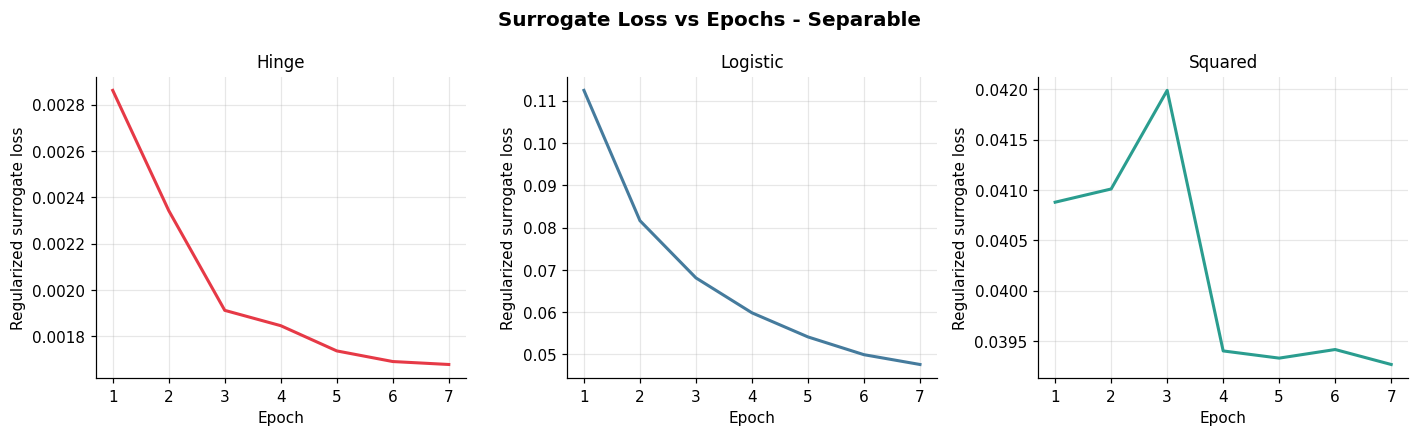

In [252]:
plot_surr_vs_epoch(r_sep, 'Surrogate Loss vs Epochs - Separable')

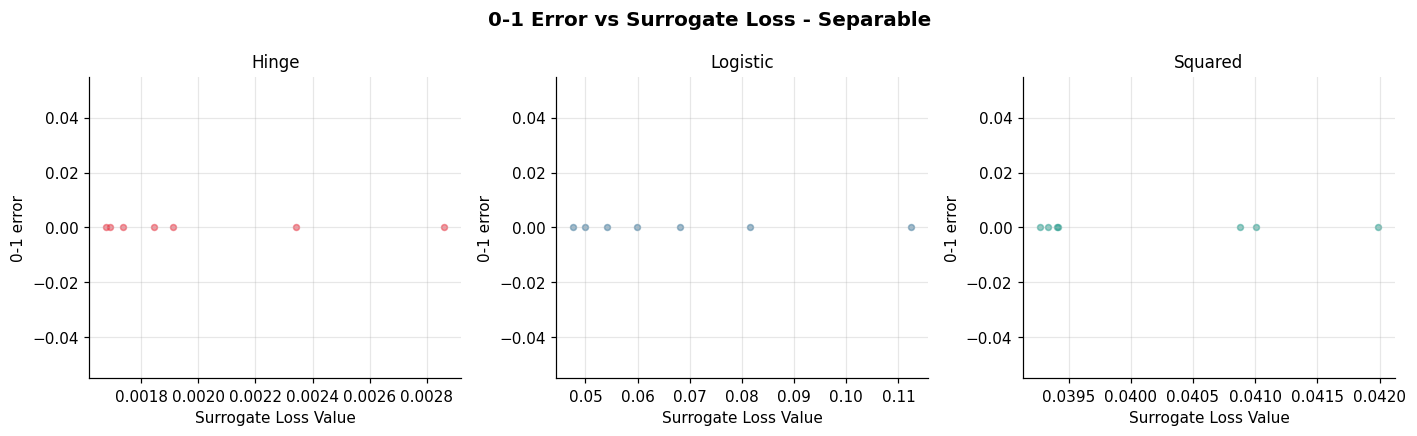

In [260]:
plot_err_vs_surr(r_sep, '0-1 Error vs Surrogate Loss - Separable')

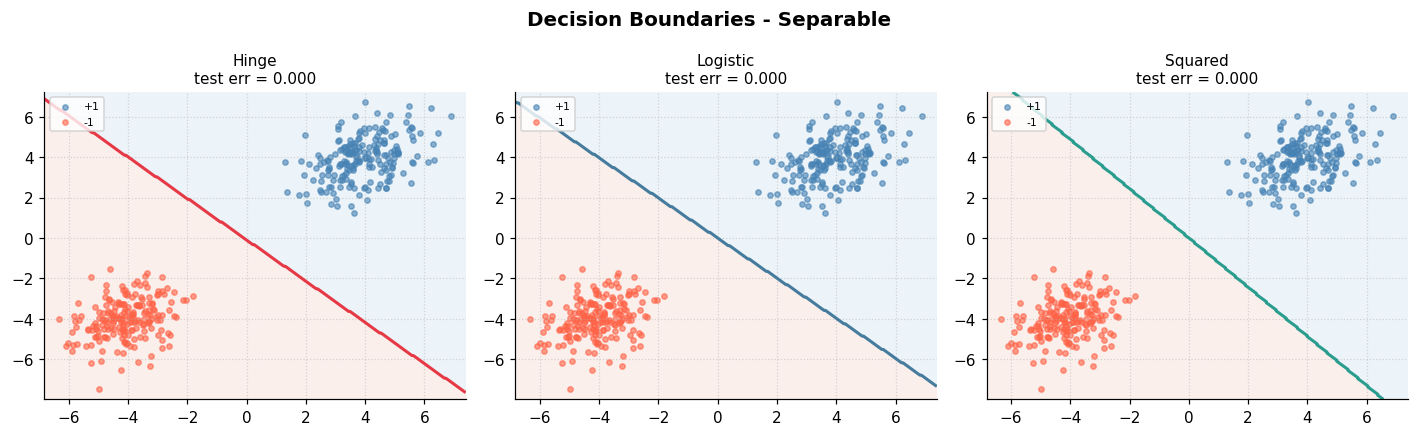

In [279]:
plot_boundaries(r_sep, X_sep, y_sep, 'Decision Boundaries - Separable')

### Non-Separable Data

In [238]:
X_non_sep, y_non_sep = generate_data_gaussian(400, separable=False)
X_ns_train, X_ns_test, y_ns_train, y_ns_test = split_scale_set( X_non_sep, y_non_sep, test_size=0.25, random_seed=RANDOM_SEED)

print("=== Non-Separable dataset ===")
r_ns = run_all(X_ns_train, y_ns_train, X_ns_test, y_ns_test, T = 2000, lam = 0.01, eta_0=0.1)

=== Non-Separable dataset ===
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.177      0.180       0.4122
  Logistic                0.173      0.180       0.3893
  Squared                 0.190      0.190       0.5227


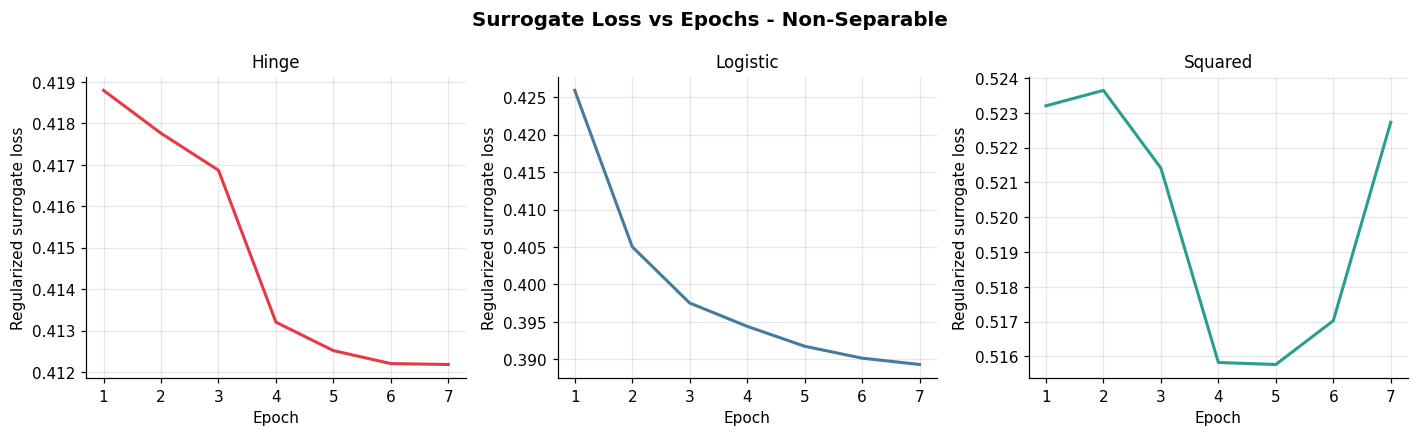

In [239]:
plot_surr_vs_epoch(r_ns, 'Surrogate Loss vs Epochs - Non-Separable')

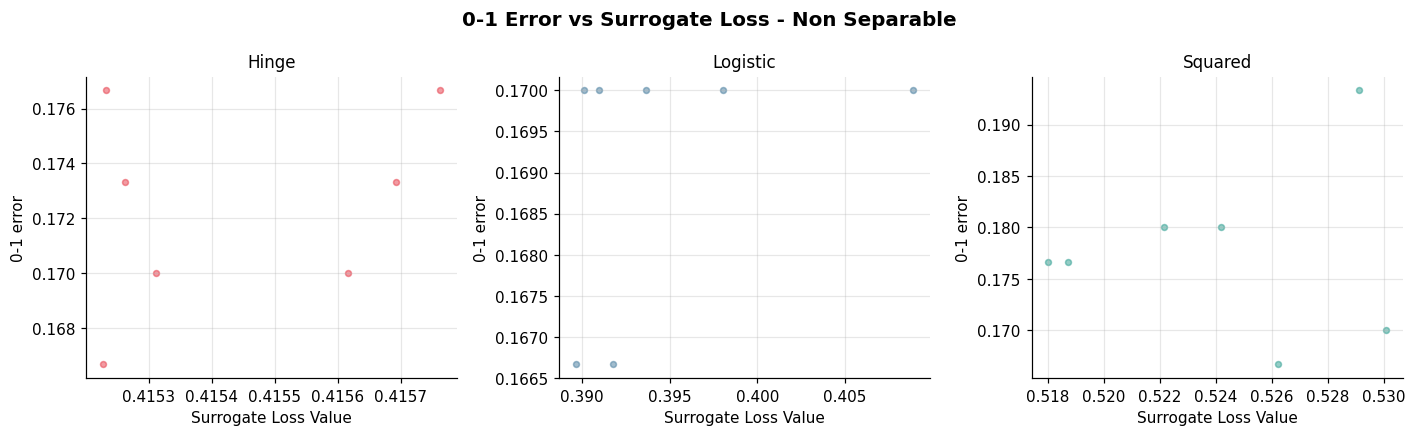

In [163]:
plot_err_vs_surr(r_ns, '0-1 Error vs Surrogate Loss - Non Separable')

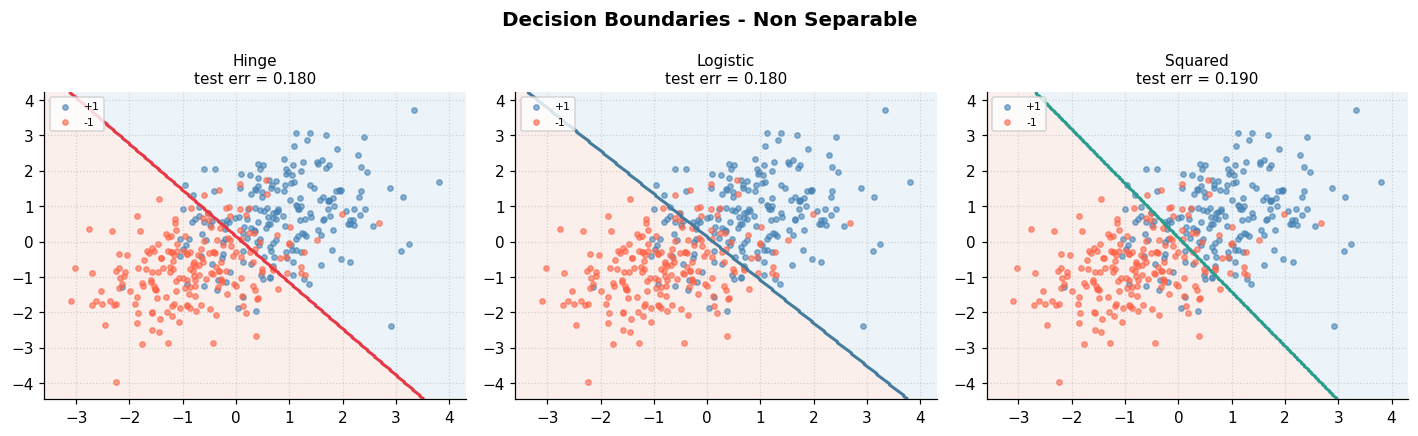

In [281]:
plot_boundaries(r_ns, X_non_sep, y_non_sep, 'Decision Boundaries - Non Separable')

### Real-World dataset (IRIS)

In [288]:
X_real, y_real = load_real_dataset()
X_real_train, X_real_test, y_real_train, y_real_test = split_scale_set(X_real, y_real, test_size=0.25, random_seed=RANDOM_SEED)

print("=== Iris Dataset ===")
r_rw = run_all(X_real_train, y_real_train, X_real_test, y_real_test, T=2000, lam=0.01, eta_0=0.05)

=== Iris Dataset ===
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.000      0.040       0.2143
  Logistic                0.013      0.120       0.4802
  Squared                 0.013      0.040       0.1770


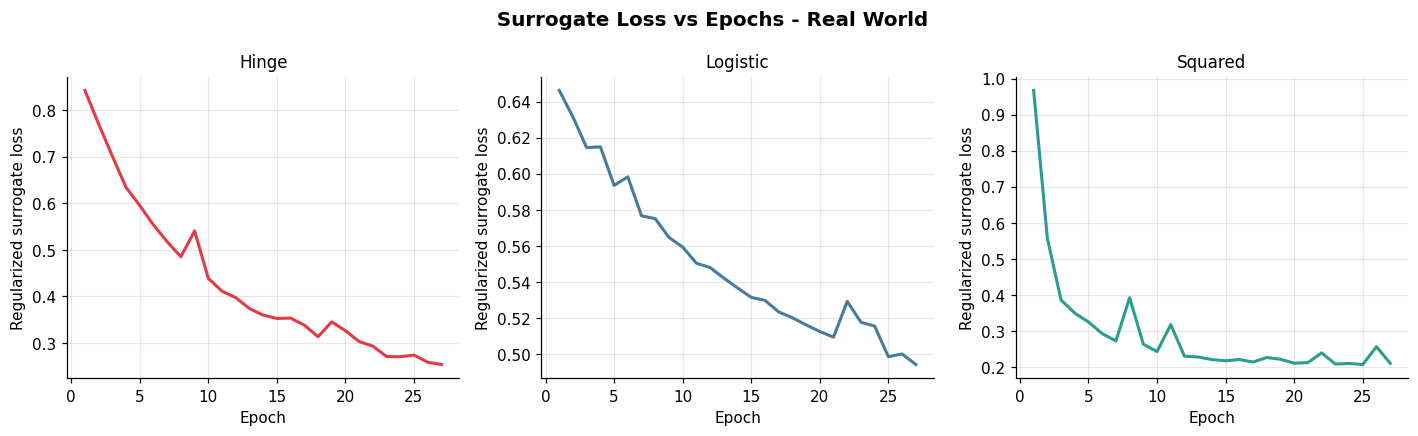

In [ ]:
plot_surr_vs_epoch(r_rw, ' Surrogate Loss vs Epochs - Real World')  

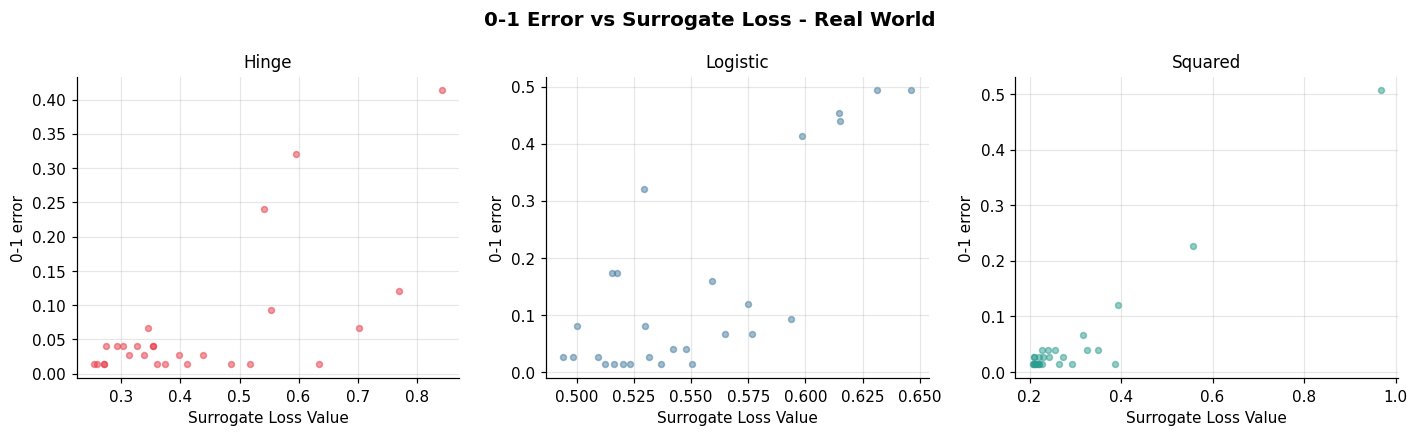

In [200]:
plot_err_vs_surr(r_rw, '0-1 Error vs Surrogate Loss - Real World')

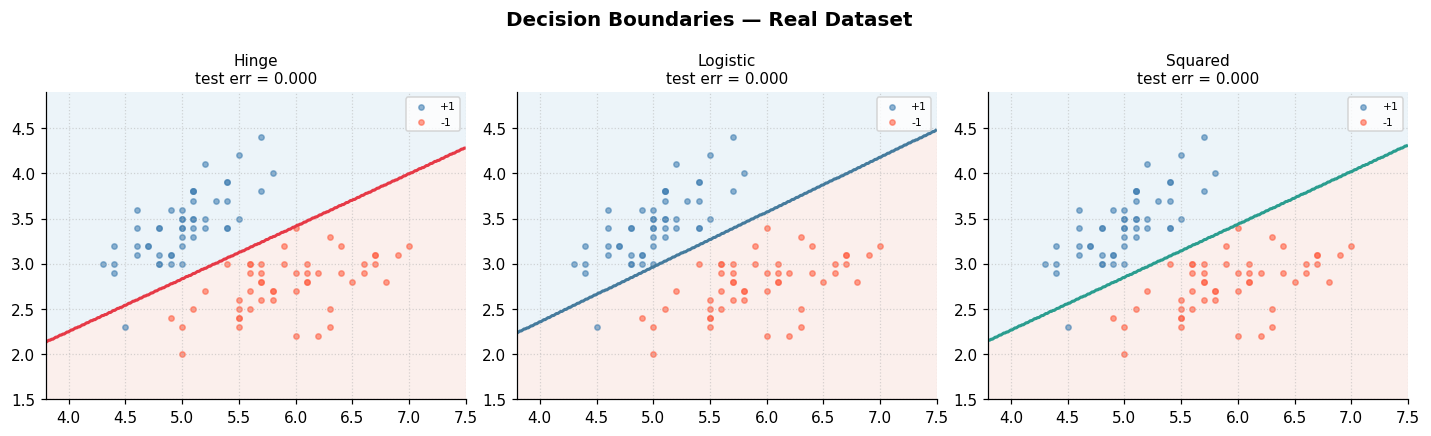

In [283]:
plot_boundaries(r_rw,    X_real, y_real, 'Decision Boundaries — Real Dataset')

### Effects of regularization

In [293]:
# Define a range of lambda values to test the effect of regularization
lambdas = [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0]

for l in lambdas:
    print("\n" + "="*60)
    print(f" EXPERIMENT: Lambda = {l}")
    print("="*60)
    
    # Train with that lambda
    results = run_all(X_sep_train, y_sep_train, X_sep_test, y_sep_test, T=2000, lam=l, eta_0=0.05)


 EXPERIMENT: Lambda = 0.0
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.000      0.000       0.0007
  Logistic                0.000      0.000       0.0102
  Squared                 0.000      0.000       0.0407

 EXPERIMENT: Lambda = 0.0001
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.000      0.000       0.0001
  Logistic                0.000      0.000       0.0102
  Squared                 0.000      0.000       0.0392

 EXPERIMENT: Lambda = 0.001
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.000      0.000       0.0001
  Logistic                0.000      0.000       0.0107
  Squared                 0.000      0.000       0.0390

 EXPERIMENT: Lambda = 0.01
  Loss                train_err   test_err 

In [294]:
# Define a range of lambda values to test the effect of regularization
lambdas = [0.0, 0.0001, 0.001, 0.01, 0.1, 1.0]

for l in lambdas:
    print("\n" + "="*60)
    print(f" EXPERIMENT: Lambda = {l}")
    print("="*60)
    
    # Train with that lambda
    results = run_all(X_real_train, y_real_train, X_real_test, y_real_test, T=2000, lam=l, eta_0=0.05)


 EXPERIMENT: Lambda = 0.0
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.000      0.040       0.1963
  Logistic                0.080      0.080       0.4775
  Squared                 0.000      0.040       0.1684

 EXPERIMENT: Lambda = 0.0001
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.013      0.040       0.2036
  Logistic                0.027      0.080       0.4706
  Squared                 0.027      0.040       0.1717

 EXPERIMENT: Lambda = 0.001
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.027      0.040       0.2032
  Logistic                0.040      0.040       0.4706
  Squared                 0.000      0.040       0.1624

 EXPERIMENT: Lambda = 0.01
  Loss                train_err   test_err 

### SGD with Momentum

In [ ]:

    #Stochastic Gradient Descent with Momentum
    #Input: X = array of features, y = array of labels, loss_fn = loss function, grad_fn = gradient update function
    #       T=number of SGD rounds, lam = regularization term, eta_0 = starting learning rate, beta = momentum decay factor
    #Output: w_avg = weight average with bias, surr_hist = regularized surrogate loss recorded per epoch, err_hist = 0-1 training error recorded per epoch
def Momentum_sgd_train(X,y,loss_fn, grad_fn, T=2000, lam= 0.01, eta_0 = 0.05, beta = 0.9):
    
    n = X.shape[0]

    # in order to have homogeneous hyperplane we add extra feature with value 1
    X_aug = np.hstack([np.ones((n,1)),X])

    # set w1 = 0
    w = np.zeros(X_aug.shape[1])

    #  same shape as w
    v = np.zeros(X_aug.shape[1])

    w_history = []              
    surrLoss_history = []       
    error_history = []          

    epoch_size = n             

    for t in range(1,T+1):

        # draw Zt at random
        idx = np.random.randint(0,n)
        x_t = X_aug[idx]
        y_t = y[idx]

        eta_t = eta_0 / np.sqrt(t)

        grad = grad_fn(w, x_t, y_t, lam)

        #update velocity
        v = beta * v + eta_t * grad
        w = w - v

        w_history.append(w.copy())

        if t % epoch_size == 0 or t == T:
            surrLoss_history.append(loss_fn(w, X_aug, y, lam))
            error_history.append(zero_one_error(w, X_aug, y))   
        
    w_avg = np.mean(w_history, axis=0)

    return w_avg, surrLoss_history, error_history


 STANDARD SGD
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.000      0.040       0.1915
  Logistic                0.000      0.080       0.4736
  Squared                 0.000      0.040       0.1620

SGD WITH MOMENTUM
  Loss                train_err   test_err  surr (last)
  ------------------------------------------------------
  Hinge                   0.000      0.040       0.0431
  Logistic                0.000      0.040       0.1449
  Squared                 0.027      0.040       0.1994


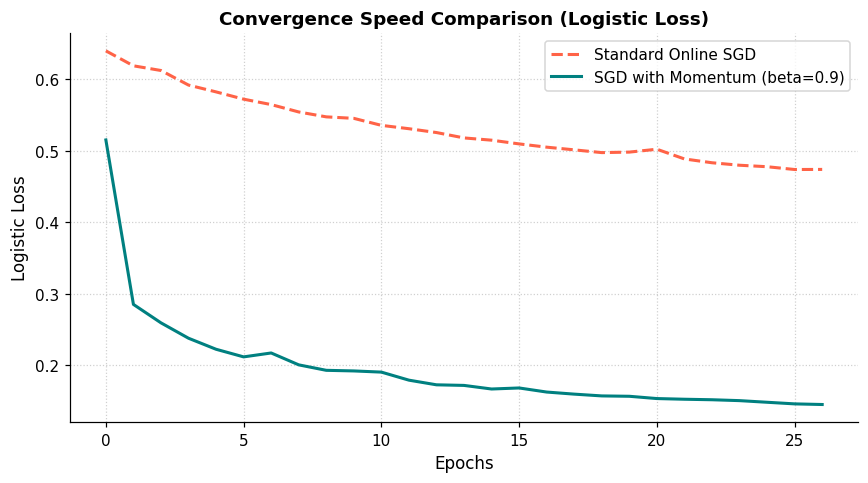

In [301]:
T_test = 2000
lam_test = 0.001
eta_test = 0.05
beta_test = 0.9

X_real_test_aug = np.hstack([np.ones((X_real_test.shape[0], 1)), X_real_test])

print("============================================================")
print(" STANDARD SGD")
print("============================================================")
print(f"  {'Loss':<18} {'train_err':>10} {'test_err':>10} {'surr (last)':>12}")
print('  ' + '-' * 54)

results_standard = {}
for name, (lfn, gfn) in LOSSES.items():
    w_avg, surrL_h, err_h = sgd_train(X_real_train, y_real_train, lfn, gfn, T=T_test, lam=lam_test, eta_0=eta_test)
    
    test_error = zero_one_error(w_avg, X_real_test_aug, y_real_test)
    print(f"  {name:<18} {err_h[-1]:>10.3f} {test_error:>10.3f} {surrL_h[-1]:>12.4f}")
    
    results_standard[name] = {
        'w': w_avg,
        'surrL': surrL_h,
        'err': err_h,
        'test_err': test_error,
    }

print("\n============================================================")
print("SGD WITH MOMENTUM")
print("============================================================")
print(f"  {'Loss':<18} {'train_err':>10} {'test_err':>10} {'surr (last)':>12}")
print('  ' + '-' * 54)

results_momentum = {}
for name, (lfn, gfn) in LOSSES.items():
    w_avg, surrL_h, err_h = Momentum_sgd_train(X_real_train, y_real_train, lfn, gfn, T=T_test, lam=lam_test, eta_0=eta_test, beta=beta_test)
    
    test_error = zero_one_error(w_avg, X_real_test_aug, y_real_test)
    print(f"  {name:<18} {err_h[-1]:>10.3f} {test_error:>10.3f} {surrL_h[-1]:>12.4f}")
    
    results_momentum[name] = {
        'w': w_avg,
        'surrL': surrL_h,
        'err': err_h,
        'test_err': test_error,
    }
plt.figure(figsize=(8, 4.5))

loss_name = 'Logistic' 

plt.plot(results_standard[loss_name]['surrL'], label="Standard Online SGD", color="tomato", lw=2, ls="--")
plt.plot(results_momentum[loss_name]['surrL'], label=f"SGD with Momentum (beta={beta_test})", color="teal", lw=2)
plt.xlabel("Epochs", fontsize=11)
plt.ylabel("Logistic Loss", fontsize=11)
plt.title(f"Convergence Speed Comparison ({loss_name} Loss)", fontsize=12, fontweight='bold')
plt.grid(True, ls=':', alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()